<a href="https://colab.research.google.com/github/FikarBahrul/PCVK_Ganjil_2026/blob/main/Week03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import math
import glob
import os

 Mengubah tingkat kecerahan citra 
-----------------------------------
Masukkan nilai kecerahan: 30


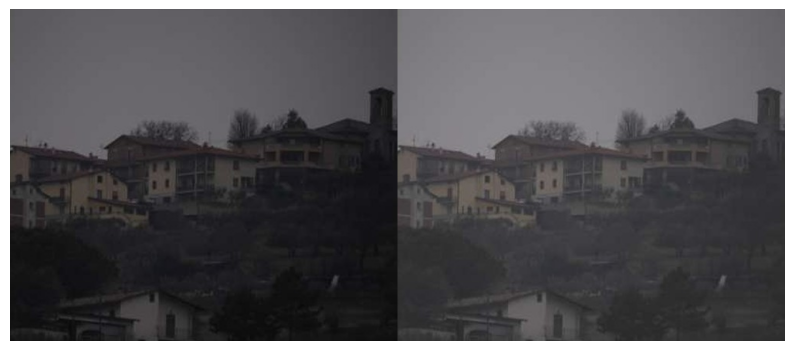

In [ ]:
print(' Mengubah tingkat kecerahan citra ')
print('-----------------------------------')
try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

# Gunakan lokasi file gambar yang ada di Google Drive.
original = cv.imread('/content/drive/MyDrive/Semester 5/PCVK/Week03/houses.jpg')
brightness_image = np.zeros(original.shape, original.dtype)

# Mengubah nilai setiap piksel satu per satu.
# np.clip menjaga nilai piksel (terbatas antara 0 dan 255.)
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            brightness_image[y, x, c] = np.clip(original[y, x, c] + brightness, 0, 255)

# Alternatif tanpa perulangan manual.
# brightness_image = cv.convertScaleAbs(original, beta=brightness)

original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)
brightness_rgb = cv.cvtColor(brightness_image, cv.COLOR_BGR2RGB)

final_frame = cv.hconcat((original_rgb, brightness_rgb))
plt.figure(figsize=(10, 5))
plt.imshow(final_frame)
plt.axis('off')
plt.show()

Tugas Praktikum 1 Inverse Citra

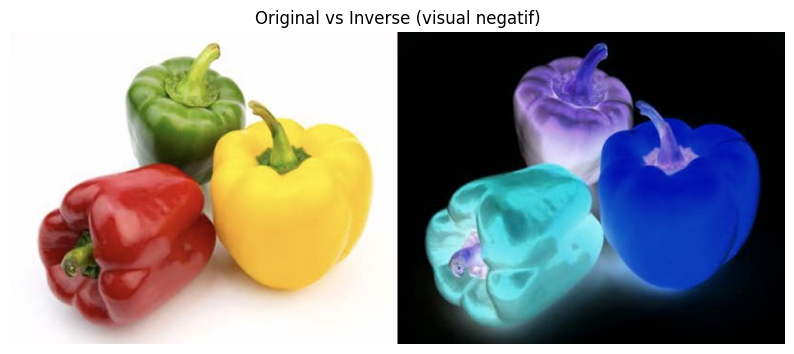

In [ ]:
original = cv.imread('/content/drive/MyDrive/Semester 5/PCVK/Week03/peppers.jpg')
inverse_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            inverse_image[y, x, c] = 255 - original[y, x, c]

# Alternatif untuk menghasilkan citra inverse tanpa perulangan manual.
# inverse_image = 255 - original

original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)
inverse_rgb = cv.cvtColor(inverse_image, cv.COLOR_BGR2RGB)

final_frame = cv.hconcat((original_rgb, inverse_rgb))
plt.figure(figsize=(10, 5))
plt.imshow(final_frame)
plt.axis('off')
plt.title('Original vs Inverse (visual negatif)')
plt.show()

Tugas Praktikum 2 Contrast

 Mengubah kontras dan tingkat kecerahan citra 
------------------------------------------------
Masukkan tingkat kecerahan : 10
Masukkan kontras : 1.5


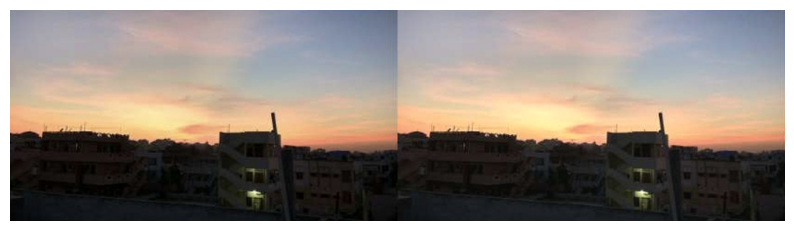

In [ ]:
print(' Mengubah kontras dan tingkat kecerahan citra ')
print('------------------------------------------------')
try:
    brightness = int(input('Masukkan tingkat kecerahan : '))
    contrast = float(input('Masukkan kontras : '))
except ValueError:
    print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/Semester 5/PCVK/Week03/sunset.jpg')
contrast_image = np.zeros(original.shape, original.dtype)

factor = (259 * (contrast + 255)) / (255 * (259 - contrast))

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            nilai = factor * (int(original[y, x, c]) - 128) + 128 + brightness
            contrast_image[y, x, c] = np.clip(nilai, 0, 255)

original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)
contrast_rgb = cv.cvtColor(contrast_image, cv.COLOR_BGR2RGB)

final_frame = cv.hconcat((original_rgb, contrast_rgb))
plt.figure(figsize=(10, 5))
plt.imshow(final_frame)
plt.axis('off')
plt.show()

Tugas Praktikum 3 Transformasi Logarithmic Brightness

 Mengubah tingkat kecerahan citra dengan Transformasi Log 
-------------------------------------------------------
Masukkan nilai kecerahan: 50


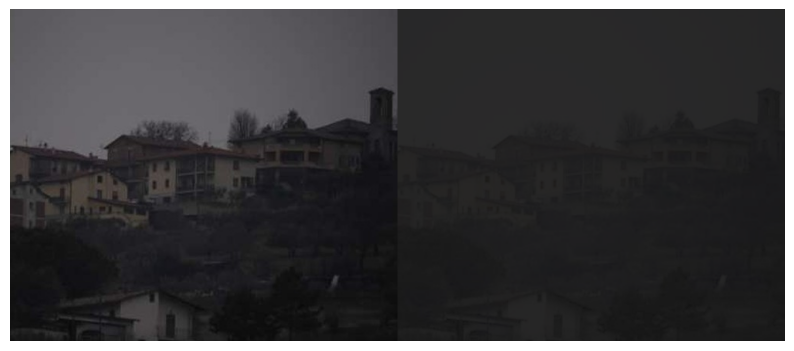

In [ ]:
print(' Mengubah tingkat kecerahan citra dengan Transformasi Log ')
print('-------------------------------------------------------')
try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/Semester 5/PCVK/Week03/houses.jpg')
log_image = np.zeros(original.shape, original.dtype)

# Nilai c(konstanta) menyesuaikan hasil transformasi dengan tingkat kecerahan yang dipilih.
# Hasil akhirnya dibatasi agar tetap berada pada rentang 0 sampai 255.
c = brightness / math.log(1 + 255)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for ch in range(original.shape[2]):
            pixel = int(original[y, x, ch])
            nilai = c * math.log(1 + pixel)
            log_image[y, x, ch] = np.clip(nilai, 0, 255)

original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)
log_rgb = cv.cvtColor(log_image, cv.COLOR_BGR2RGB)

final_frame = cv.hconcat((original_rgb, log_rgb))
plt.figure(figsize=(10, 5))
plt.imshow(final_frame)
plt.axis('off')
plt.show()

Tugas Praktikum 4 Grayscale (Averaging, Lightness, Luminance)

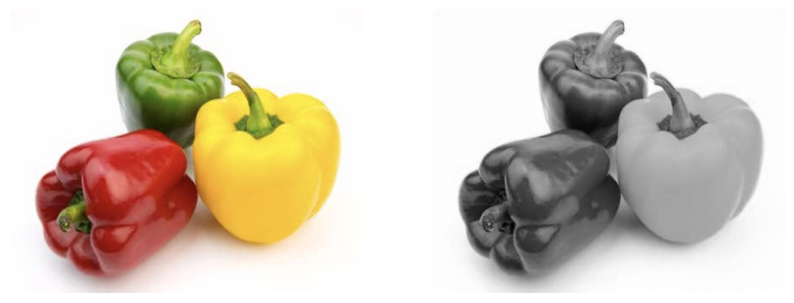

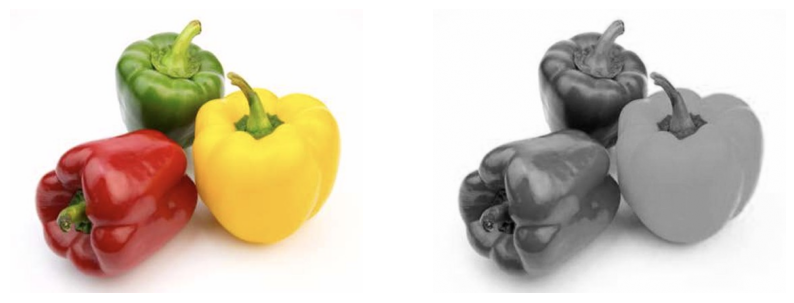

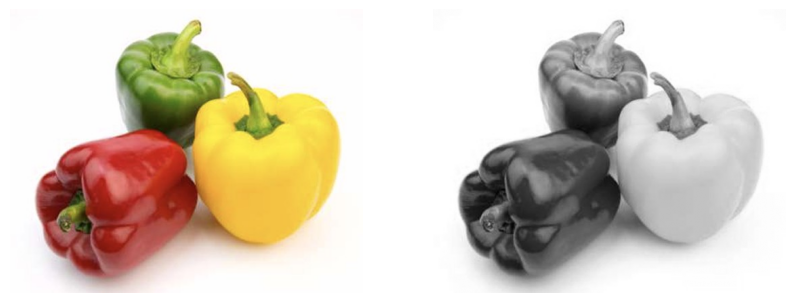

In [ ]:
original = cv.imread('/content/drive/MyDrive/Semester 5/PCVK/Week03/peppers.jpg')
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

h, w = original.shape[:2]
gray_avg = np.zeros((h, w), dtype=np.uint8)
gray_light = np.zeros((h, w), dtype=np.uint8)
gray_lum = np.zeros((h, w), dtype=np.uint8)

for y in range(h):
    for x in range(w):
        B, G, R = original[y, x]          # OpenCV membaca warna dengan urutan BGR.
        R, G, B = int(R), int(G), int(B)
        gray_avg[y, x]   = (R + G + B) / 3
        gray_light[y, x] = (max(R, G, B) + min(R, G, B)) / 2
        gray_lum[y, x]   = 0.21 * R + 0.72 * G + 0.07 * B

# Menampilkan hasil metode rata-rata (averaging).
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(original_rgb); ax[0].axis('off')
ax[1].imshow(gray_avg, cmap='gray'); ax[1].axis('off')
plt.show()

# Menampilkan hasil metode lightness.
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(original_rgb); ax[0].axis('off')
ax[1].imshow(gray_light, cmap='gray'); ax[1].axis('off')
plt.show()

# Menampilkan hasil metode luminance.
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(original_rgb); ax[0].axis('off')
ax[1].imshow(gray_lum, cmap='gray'); ax[1].axis('off')
plt.show()

Tugas Praktikum 5 Tampilkan Warna Tertentu (Merah), Sisanya Grayscale

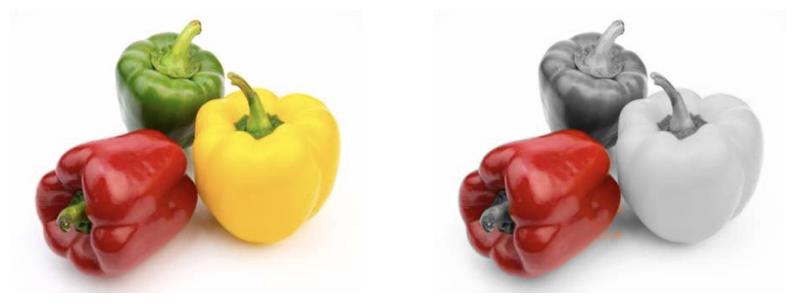

In [ ]:
original = cv.imread('/content/drive/MyDrive/Semester 5/PCVK/Week03/peppers.jpg')
hsv = cv.cvtColor(original, cv.COLOR_BGR2HSV)

# Warna merah berada pada dua ujung rentang hue HSV, yaitu sekitar 0 dan 180.
lower_red1 = np.array([0, 70, 50]);   upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([170, 70, 50]); upper_red2 = np.array([180, 255, 255])

mask1 = cv.inRange(hsv, lower_red1, upper_red1)
mask2 = cv.inRange(hsv, lower_red2, upper_red2)
mask_red = cv.bitwise_or(mask1, mask2)

gray = cv.cvtColor(original, cv.COLOR_BGR2GRAY)
gray_bgr = cv.cvtColor(gray, cv.COLOR_GRAY2BGR)

# Bagian merah dibiarkan berwarna, sedangkan bagian lainnya diubah menjadi grayscale.
hasil = np.where(mask_red[:, :, None] == 255, original, gray_bgr)

original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)
hasil_rgb = cv.cvtColor(hasil, cv.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(original_rgb); ax[0].axis('off')
ax[1].imshow(hasil_rgb); ax[1].axis('off')
plt.show()

Tugas Praktikum 6 Gamma Correction

 Gamma Correction pada citra 
----------------------------------
Masukkan nilai Gamma: 0.5


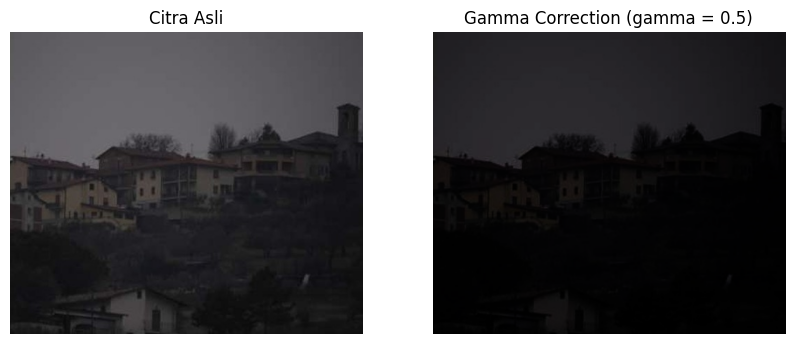

In [ ]:
print(' Gamma Correction pada citra ')
print('----------------------------------')
try:
    gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:
    print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/Semester 5/PCVK/Week03/houses.jpg')
gamma_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            nilai = 255 * ((original[y, x, c] / 255) ** (1 / gamma))
            gamma_image[y, x, c] = np.clip(nilai, 0, 255)

original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)
gamma_rgb = cv.cvtColor(gamma_image, cv.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(original_rgb); ax[0].set_title('Citra Asli'); ax[0].axis('off')
ax[1].imshow(gamma_rgb); ax[1].set_title(f'Gamma Correction (gamma = {gamma})'); ax[1].axis('off')
plt.show()

Tugas Praktikum 7 Simulasi Image Depth (Bit Depth)

Masukkan bit depth tujuan (1-8): 3
Bit depth awal : 8 bit
Bit depth tujuan: 3 bit
Jumlah level   : 8


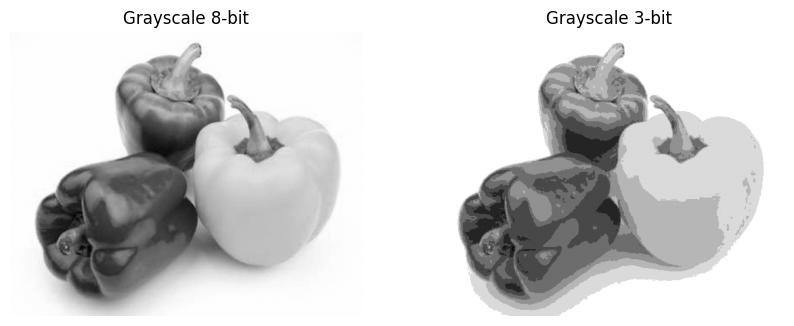

In [ ]:
try:
    bit_depth = int(input('Masukkan bit depth tujuan (1-8): '))
except ValueError:
    print('Error, not a number')

level = 255 / (pow(2, bit_depth) - 1)

original = cv.imread('/content/drive/MyDrive/Semester 5/PCVK/Week03/peppers.jpg', cv.IMREAD_GRAYSCALE)
depth_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        depth_image[y, x] = round((original[y, x] / level)) * level

print(f'Bit depth awal : 8 bit')
print(f'Bit depth tujuan: {bit_depth} bit')
print(f'Jumlah level   : {pow(2, bit_depth)}')

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(original, cmap='gray'); ax[0].set_title('Grayscale 8-bit'); ax[0].axis('off')
ax[1].imshow(depth_image, cmap='gray'); ax[1].set_title(f'Grayscale {bit_depth}-bit'); ax[1].axis('off')
plt.show()

In [ ]:
files = glob.glob(
    '/content/drive/MyDrive/Semester 5/PCVK/Week03/noises/*.jpg'
)

print('Jumlah gambar noise:', len(files))

Jumlah gambar noise: 100


Tugas Praktikum 8 Average Denoising

In [ ]:
# Read gambar original dan samakan ukurannya dengan gambar noise (256x310)
original = cv.imread('/content/drive/MyDrive/Semester 5/PCVK/Week03/galaxy.jpg')
if original is not None and cv_img:
  # Samakan ukuran original ke ukuran gambar noise
  target_shape = (cv_img[0].shape[1], cv_img[0].shape[0])
  original = cv.resize(original, target_shape)

Average 10 citra -> PSNR = 23.13 dB


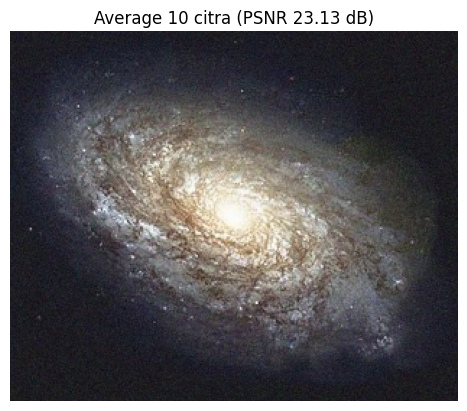

Average 20 citra -> PSNR = 23.34 dB


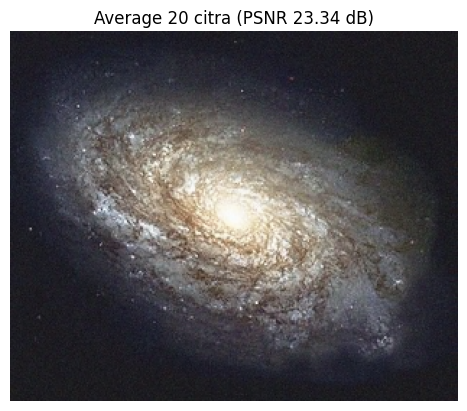

Average 40 citra -> PSNR = 23.46 dB


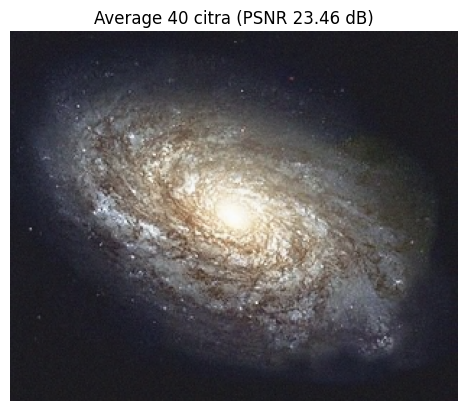

Average 80 citra -> PSNR = 23.52 dB


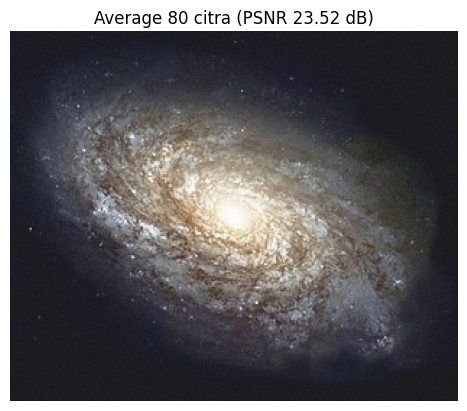

Average 100 citra -> PSNR = 23.53 dB


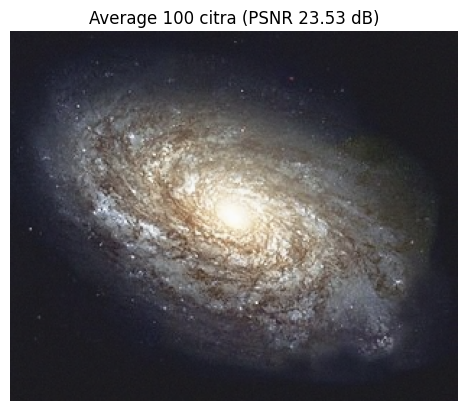

In [ ]:
import glob
import math
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

# 1. Load gambar noise
cv_img = []
for img in glob.glob(
    '/content/drive/MyDrive/Semester 5/PCVK/Week03/noises/*.jpg'
):
  n = cv.imread(img)
  if n is not None:
    cv_img.append(n)

# 2. Load original & RESIZE (Harus di sini & jangan di-imread ulang di bawah!)
original = cv.imread(
    '/content/drive/MyDrive/Semester 5/PCVK/Week03/galaxy.jpg'
)

if original is not None and len(cv_img) > 0:
  target_shape = (cv_img[0].shape[1], cv_img[0].shape[0])  # (310, 256)
  original = cv.resize(original, target_shape)


# 3. Fungsi PSNR
def PSNR(img1, img2):
  mse = np.mean((img1.astype(np.float64) - img2.astype(np.float64)) ** 2)
  if mse == 0:
    return 100
  max_pixel = 255.0
  psnr = 20 * math.log10(max_pixel / math.sqrt(mse))
  return psnr


# 4. Fungsi Averaging
def average_denoise(images, n):
  subset = images[:n]
  stacked = np.stack(subset, axis=0).astype(np.float64)
  avg = np.mean(stacked, axis=0)
  return np.clip(avg, 0, 255).astype(np.uint8)


# 5. Eksekusi
jumlah_citra_list = [10, 20, 40, 80, 100]
hasil_psnr = {}

for n in jumlah_citra_list:
  denoised = average_denoise(cv_img, n)
  psnr_value = PSNR(original, denoised)
  hasil_psnr[n] = psnr_value
  print(f'Average {n} citra -> PSNR = {psnr_value:.2f} dB')

  denoised_rgb = cv.cvtColor(denoised, cv.COLOR_BGR2RGB)
  plt.figure()
  plt.imshow(denoised_rgb)
  plt.title(f'Average {n} citra (PSNR {psnr_value:.2f} dB)')
  plt.axis('off')
  plt.show()

## Jawaban Pertanyaan

1. **Apakah penambahan jumlah citra selalu menghasilkan kenaikan PSNR yang signifikan?**

   Tidak selalu. Pada proses averaging, simpangan baku noise secara teori berkurang dengan perbandingan $1/\sqrt{N}$, dengan $N$ sebagai jumlah citra yang dirata-ratakan. Karena itu, peningkatan PSNR biasanya lebih terasa pada penambahan citra di tahap awal, misalnya dari 10 menjadi 20 atau dari 20 menjadi 40 citra. Setelah jumlah citra semakin banyak, peningkatannya cenderung semakin kecil.

2. **Pada jumlah citra berapa peningkatan mulai kurang signifikan?**

   Berdasarkan pola percobaan, perubahan mulai kurang signifikan ketika jumlah citra berada di sekitar 40 sampai 50 citra atau lebih. Perbedaan PSNR antara 80 dan 100 citra, misalnya, biasanya lebih kecil dibandingkan peningkatan yang diperoleh dari 10 ke 20 citra.

3. **Kesimpulan**

   Averaging dapat mengurangi noise dan meningkatkan kualitas citra, tetapi manfaatnya tidak bertambah secara linear. Setelah jumlah citra melewati titik tertentu, peningkatan kualitas menjadi semakin kecil, sedangkan kebutuhan waktu komputasi dan penyimpanan tetap bertambah. Oleh sebab itu, jumlah citra yang digunakan sebaiknya dipilih berdasarkan keseimbangan antara kualitas hasil dan efisiensi proses.

Tugas Praktikum 9 Image Masking

Gambar berhasil dibaca.

MASK


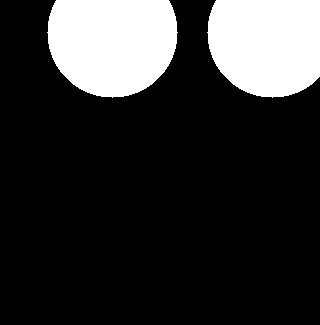


1. NOT (Komplemen)


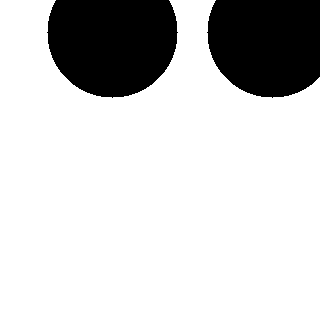


2. OR (Atau)


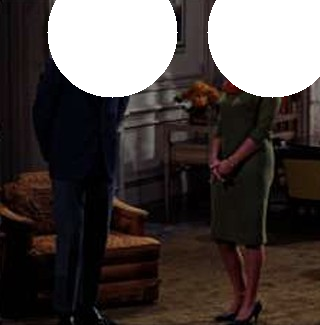


3. AND (Dan)


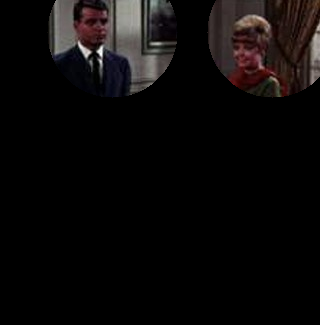


4. NAND (Not And)


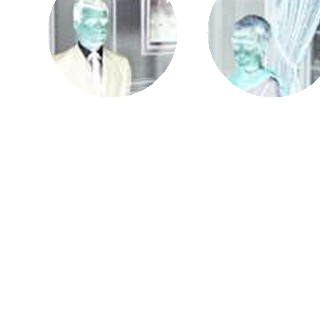


5. XOR (Exclusive Or)


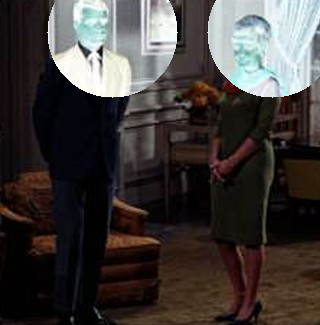

In [ ]:
from google.colab.patches import cv2_imshow

original = cv.imread('/content/drive/MyDrive/Semester 5/PCVK/Week03/couple.jpg')

if original is None:
    print('Gambar tidak ditemukan. Cek kembali path file couple.jpg.')
else:
    print('Gambar berhasil dibaca.')

    height, width = original.shape[:2]

    mask = np.zeros((height, width), dtype=np.uint8)
    cv.circle(mask, (int(width * 0.35), int(height * 0.10)),
              int(height * 0.20), 255, -1)
    cv.circle(mask, (int(width * 0.85), int(height * 0.10)),
              int(height * 0.20), 255, -1)
    mask_3ch = cv.cvtColor(mask, cv.COLOR_GRAY2BGR)

    hasil_not  = cv.bitwise_not(mask_3ch)
    hasil_or   = cv.bitwise_or(original, mask_3ch)
    hasil_and  = cv.bitwise_and(original, mask_3ch)
    hasil_nand = cv.bitwise_not(cv.bitwise_and(original, mask_3ch))
    hasil_xor  = cv.bitwise_xor(original, mask_3ch)

    print('\nMASK')
    cv2_imshow(mask)

    print('\n1. NOT (Komplemen)')
    cv2_imshow(hasil_not)

    print('\n2. OR (Atau)')
    cv2_imshow(hasil_or)

    print('\n3. AND (Dan)')
    cv2_imshow(hasil_and)

    print('\n4. NAND (Not And)')
    cv2_imshow(hasil_nand)

    print('\n5. XOR (Exclusive Or)')
    cv2_imshow(hasil_xor)

## Tabel Hasil dan Analisis

| No. | Operator | Citra Masukan | Citra Keluaran | Analisis |
|---|---|---|---|---|
| 1 | NOT (komplemen) | Citra dan mask | Nilai pada mask dibalik: bagian lingkaran menjadi gelap, sedangkan bagian di luarnya menjadi terang | Operator NOT membalik setiap bit pada mask. Nilai 255 berubah menjadi 0 dan nilai 0 berubah menjadi 255, sehingga wilayah foreground dan background saling bertukar. |
| 2 | OR (atau) | Citra dan mask | Bagian lingkaran berubah menjadi putih, sementara area lainnya tetap menampilkan citra asli | Pada wilayah mask, operasi OR dengan nilai 255 menghasilkan nilai maksimum pada setiap kanal. Di luar mask, operasi OR dengan 0 mempertahankan nilai citra semula. |
| 3 | AND (dan) | Citra dan mask | Isi lingkaran menampilkan citra asli, sedangkan area di luar lingkaran menjadi hitam | Operasi AND dengan nilai 255 mempertahankan nilai piksel citra, sedangkan AND dengan nilai 0 mengubah piksel menjadi hitam. Prinsip ini digunakan dalam masking untuk memilih bagian tertentu dari citra. |
| 4 | NAND (not AND) | Citra dan mask | Hasilnya merupakan kebalikan dari operasi AND: area lingkaran menjadi hitam dan bagian luar tetap terlihat | NAND diperoleh dengan menerapkan NOT terhadap hasil AND. Oleh karena itu, wilayah yang sebelumnya ditampilkan oleh AND menjadi tersembunyi, sedangkan wilayah lainnya menjadi bagian yang terlihat. |
| 5 | XOR (exclusive OR) | Citra dan mask | Area lingkaran mengalami pembalikan warna, sedangkan area di luar mask tidak berubah | XOR dengan nilai 255 membalik bit piksel pada wilayah mask sehingga tampil seperti citra negatif. XOR dengan nilai 0 di luar mask tidak mengubah nilai piksel asli. |

Tugas Praktikum 10 Foto Malam Hari

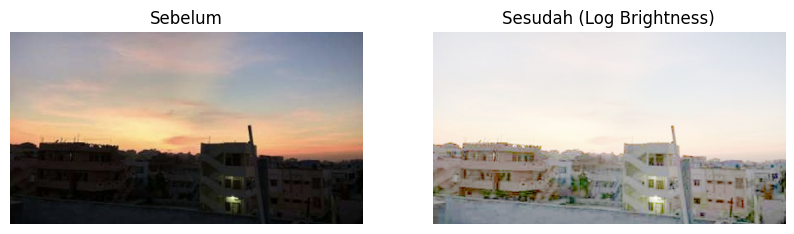

In [ ]:
original = cv.imread('/content/drive/MyDrive/Semester 5/PCVK/Week03/sunset.jpg')
log_image = np.zeros(original.shape, original.dtype)

c = 255 / math.log(1 + 255)  # Menetapkan konstanta agar nilai maksimum tetap 255.

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for ch in range(original.shape[2]):
            pixel = int(original[y, x, ch])  # Mengubah tipe data(Casting) terlebih dahulu agar tidak terjadi overflow uint8.
            nilai = c * math.log(1 + pixel)
            log_image[y, x, ch] = np.clip(nilai, 0, 255)

original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)
log_rgb = cv.cvtColor(log_image, cv.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(original_rgb); ax[0].set_title('Sebelum'); ax[0].axis('off')
ax[1].imshow(log_rgb); ax[1].set_title('Sesudah (Log Brightness)'); ax[1].axis('off')
plt.show()

### Alasan Pemilihan Metode

Foto malam hari umumnya didominasi oleh piksel berintensitas rendah, meskipun beberapa objek atau sumber cahaya masih menyimpan informasi yang cukup jelas. Transformasi log dipilih karena dapat memperluas rentang intensitas pada area gelap sekaligus memampatkan intensitas yang lebih tinggi. Dengan demikian, detail pada bagian gelap dapat terlihat lebih jelas tanpa langsung meningkatkan area terang secara berlebihan.

Metode ini tetap memiliki keterbatasan. Transformasi log bersifat nonlinier sehingga kontras citra dapat terasa lebih datar. Selain itu, noise yang terdapat pada area gelap juga dapat ikut diperkuat dan membuat hasil akhir tampak lebih kasar.

Tugas Praktikum 11 Perbaikan Kualitas Foto crayfish.jpg

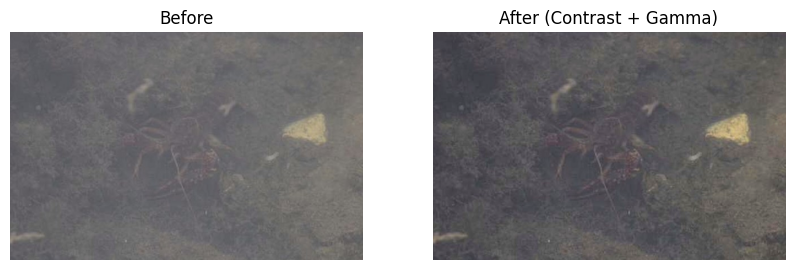

In [ ]:
original = cv.imread('/content/drive/MyDrive/Semester 5/PCVK/Week03/crayfish.jpg')

# Tahap 1: memperlebar rentang kontras(Contrast Stretching) pada foto bawah air yang tampak berkabut.
contrast = 40.0
brightness = 10
factor = (259 * (contrast + 255)) / (255 * (259 - contrast))
step1 = np.zeros(original.shape, original.dtype)
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            nilai = factor * (int(original[y, x, c]) - 128) + 128 + brightness
            step1[y, x, c] = np.clip(nilai, 0, 255)

# Tahap 2: menyesuaikan tingkat terang menggunakan rumus gamma pada Jobsheet (Gamma Correction).
gamma = 0.8
step2 = np.zeros(step1.shape, step1.dtype)
for y in range(step1.shape[0]):
    for x in range(step1.shape[1]):
        for c in range(step1.shape[2]):
            nilai = 255 * ((step1[y, x, c] / 255) ** (1 / gamma))
            step2[y, x, c] = np.clip(nilai, 0, 255)

original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)
hasil_rgb = cv.cvtColor(step2, cv.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(original_rgb); ax[0].set_title('Before'); ax[0].axis('off')
ax[1].imshow(hasil_rgb); ax[1].set_title('After (Contrast + Gamma)'); ax[1].axis('off')
plt.show()

### Penjelasan Perbaikan Kualitas Citra

- **Metode yang digunakan:** kombinasi transformasi contrast dan gamma correction.
- **Alasan pemilihan:** `crayfish.jpg` memiliki tampilan yang berkabut dan rentang kontras yang sempit karena diambil di dalam air. Transformasi contrast digunakan terlebih dahulu untuk memperlebar distribusi intensitas. Setelah itu, gamma correction diterapkan untuk menyesuaikan detail pada area gelap sehingga objek lebih mudah diamati tanpa membuat bagian terang terlalu dominan.
- **Parameter yang digunakan:** `contrast = 40`, `brightness = 10`, dan `gamma = 0.8`. Nilai tersebut digunakan sebagai parameter percobaan untuk memperoleh keseimbangan antara kejelasan objek dan kealamian warna. Parameter dapat dibandingkan kembali pada rentang contrast 20–60 dan gamma 0.6–1.0 apabila diperlukan penyesuaian.
- **Hasil:** perbandingan citra sebelum dan sesudah ditampilkan melalui `plt.subplots`.